
<h1><center>EIE 401 - PROCESAMIENTO DIGITAL MULTIMEDIA</center></h1>
<h2><center>Guía de Apoyo: Ejercicios Practicap ara actividad 1</center></h2>

<center><h3>Profesor: Jorge Cárdenas</h3></center>
<center><h3>Ayudante: Mauricio Schmidt</h3></center>

<center><h5>Pontificia Universidad Católica de Valparaíso</h5></center>

<hr>

<h2><center>Presentación</center></h2>

<p>
La presente guía tiene como objetivo apoyar el desarrollo de la actividad práctica del curso,
mediante ejercicios resueltos orientados a los contenidos de ruido, muestreo y cuantización.
</p>

<p>
El foco de este material es reforzar la comprensión de los conceptos, la interpretación de resultados
y la implementación en Python, de modo que el estudiante cuente con una base de trabajo para abordar
la actividad evaluada de manera autónoma.
</p>

<hr>

<h2><center>Recomendaciones de Uso</center></h2>

<ul>
<li>Revisar primero el enunciado de cada ejercicio antes de ejecutar el código.</li>
<li>Analizar cada gráfico obtenido y contrastarlo con la teoría vista en clases.</li>
<li>Modificar parámetros como frecuencia, amplitud, ruido o número de bits para observar cambios.</li>
<li>Utilizar esta guía como material de práctica previa a la actividad con nota.</li>
</ul>

<hr>


<h2><center>Ejercicio 1: Ruido Gaussiano y Señal Contaminada</center></h2>

<h3>Objetivo</h3>

<p>
Modelar ruido gaussiano, analizar su distribución estadística y observar su efecto sobre una señal senoidal.
</p>

<h3>Enunciado</h3>

<ol>
<li>Generar 10,000 muestras de una distribución normal con media 0 y desviación estándar 1.</li>
<li>Graficar el histograma del ruido generado.</li>
<li>Crear una señal senoidal pura de 44 Hz.</li>
<li>Agregar ruido gaussiano a la señal.</li>
<li>Graficar la señal pura, el ruido y la señal contaminada.</li>
</ol>

<hr>

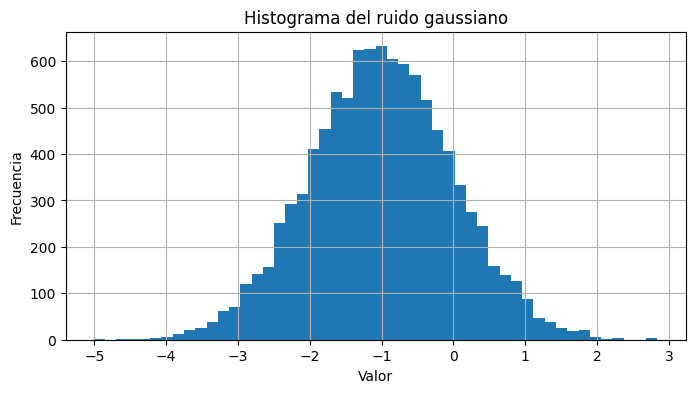

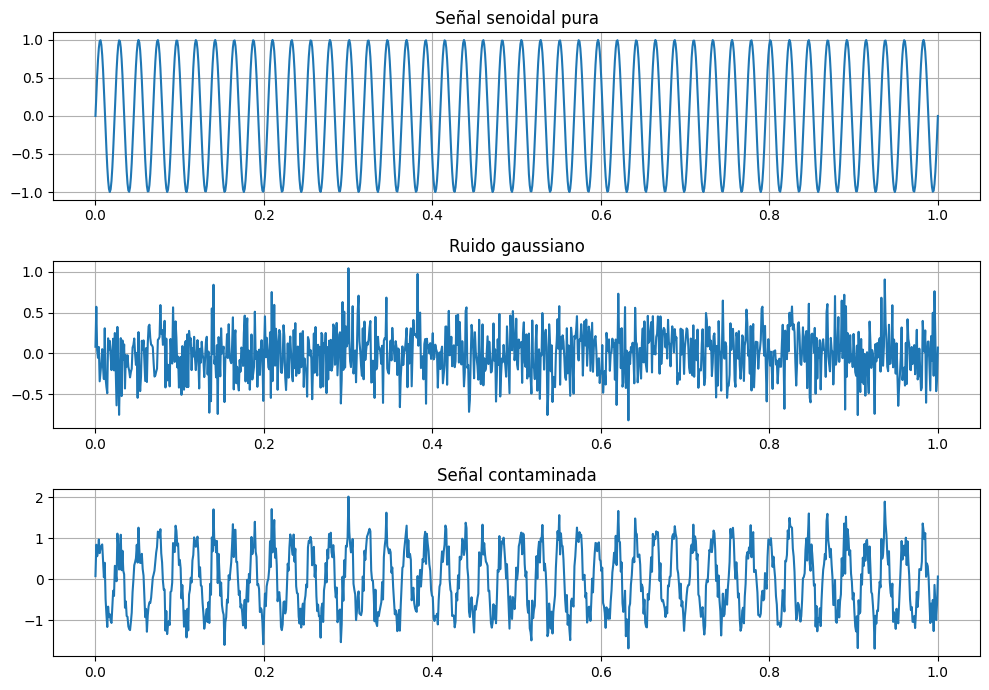

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del ruido
mu = -1
sigma = 1
n_muestras = 10000

# Generación de ruido gaussiano
ruido = np.random.normal(mu, sigma, n_muestras)

# Histograma del ruido
plt.figure(figsize=(8,4))
plt.hist(ruido, bins=50)
plt.title("Histograma del ruido gaussiano")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

# Parámetros de la señal
fs = 1000
t = np.linspace(0, 1, fs)
f = 44

# Señal pura
senal = np.sin(2 * np.pi * f * t)

# Ruido ajustado al largo de la señal
ruido_senal = np.random.normal(0, 0.3, len(t))

# Señal contaminada
senal_ruidosa = senal + ruido_senal

# Gráficos
plt.figure(figsize=(10,7))

plt.subplot(3,1,1)
plt.plot(t, senal)
plt.title("Señal senoidal pura")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t, ruido_senal)
plt.title("Ruido gaussiano")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(t, senal_ruidosa)
plt.title("Señal contaminada")
plt.grid(True)

plt.tight_layout()
plt.show()


<h2><center>Ejercicio 2: Cuantización y Resolución de Bits</center></h2>

<h3>Objetivo</h3>

<p>
Simular el proceso de discretización en amplitud y analizar su efecto sobre una señal senoidal.
</p>

<h3>Enunciado</h3>

<ol>
<li>Generar una señal senoidal de 5 Hz.</li>
<li>Cuantizar la señal a 3 bits (8 niveles).</li>
<li>Calcular la señal cuantizada.</li>
<li>Graficar la señal original y la señal cuantizada.</li>
</ol>

<hr>

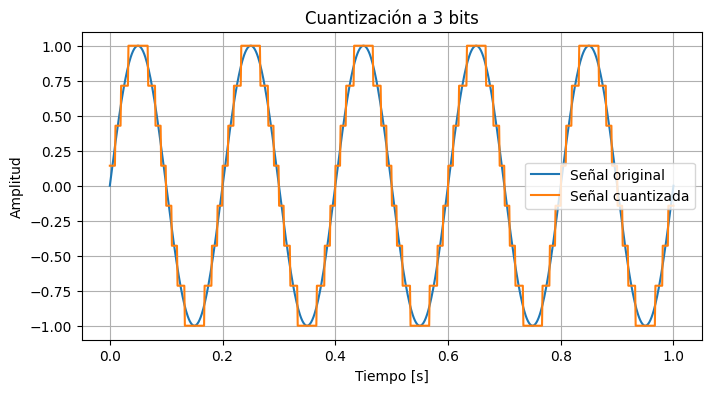

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generar señal senoidal
t = np.linspace(0, 1, 1000)
x = np.sin(2 * np.pi * 5 * t)

# 2. Parámetros de cuantización
bits = 3
niveles = 2**bits

# 3. Cuantización
x_min = min(x)
x_max = max(x)

xq = np.round((x - x_min) / (x_max - x_min) * (niveles - 1))
xq = xq / (niveles - 1) * (x_max - x_min) + x_min

# 4. Gráfica
plt.figure(figsize=(8,4))
plt.plot(t, x, label="Señal original")
plt.plot(t, xq, label="Señal cuantizada")

plt.title("Cuantización a 3 bits")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

<h2><center>Ejercicio 3: Análisis Espectral de Señal</center></h2>

<p>
Un sistema rotatorio opera nominalmente a una frecuencia fundamental de 50 Hz. Sin embargo, debido a 
imperfecciones mecánicas no lineales, se introduce una componente armónica adicional cercana al doble 
de la frecuencia base. Además, el sistema está inmerso en un entorno con ruido aleatorio significativo, 
lo que dificulta la identificación directa de las componentes en el dominio temporal.
</p>

<h3>Tarea</h3>

<ol>
<li>Generar una señal que contenga una componente de 50 Hz y otra cercana a 100 Hz.</li>
<li>Agregar ruido gaussiano a la señal.</li>
<li>Analizar la señal en el dominio de la frecuencia utilizando la FFT.</li>
<li>Identificar las frecuencias principales presentes en la señal.</li>
</ol>

<hr>

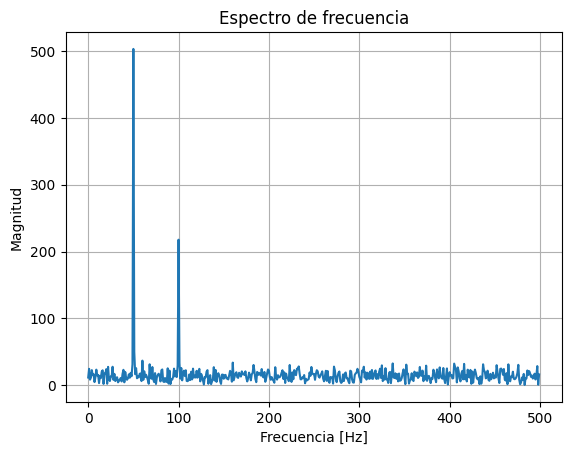

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
fs = 1000
t = np.linspace(0, 1, fs)

# Señal base + armónica
x = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 100 * t)

# Ruido
ruido = np.random.normal(0, 0.5, len(t))
x_ruido = x + ruido

# FFT
X = np.fft.fft(x_ruido)
frecuencias = np.fft.fftfreq(len(t), 1/fs)

# Solo frecuencias positivas
mitad = len(frecuencias)//2
frecuencias = frecuencias[:mitad]
X = np.abs(X[:mitad])

# Gráfico
plt.plot(frecuencias, X)
plt.title("Espectro de frecuencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid(True)
plt.show()

<h2><center>Ejercicio 4: Muestreo y Teorema de Nyquist</center></h2>

<h3><center>4.1 Señal Impulso</center></h3>

<p style="text-align: center;">
Analizaremos una señal discreta tipo impulso y su comportamiento en el tiempo.
</p>

<h3>Tarea</h3>

<ol>
<li>Generar una señal delta δ(n) discreta.</li>
<li>Desplazar el impulso en el tiempo.</li>
<li>Graficar la señal original y la señal desplazada.</li>
</ol>

<hr>

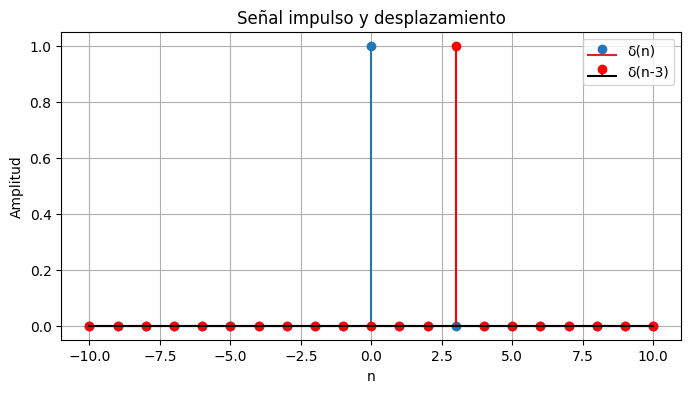

In [7]:

import numpy as np
import matplotlib.pyplot as plt

# Eje discreto
n = np.arange(-10, 11)

# Señal impulso
delta = np.zeros(len(n))
delta[n == 0] = 1

# Impulso desplazado
delta_shift = np.zeros(len(n))
delta_shift[n == 3] = 1

# Gráficos
plt.figure(figsize=(8,4))

plt.stem(n, delta, label="δ(n)")
plt.stem(n, delta_shift, linefmt='r-', markerfmt='ro', basefmt='k-', label="δ(n-3)")

plt.title("Señal impulso y desplazamiento")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)

plt.show()